In [1]:
import os
os.chdir(r"E:\Future Interns\Task 3 - Resume  Candidate Screening System\Code")
os.getcwd()

'E:\\Future Interns\\Task 3 - Resume  Candidate Screening System\\Code'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [3]:
jd_df=pd.read_csv("filtered_jd_df.csv")
jd_df.head()

,Job Title,Role,Job Description,skills,Work Type,Responsibilities,Qualifications,Experience,Clean Responsibilities,JD_Word_Count,skills_Word_Count,Responsibilities_Word_Count
0,digital marketing specialist,social media manager,social media managers oversee an organizations...,"social media platforms (e.g., facebook, twitte...",intern,"manage and grow social media accounts, create ...",m.tech,5 to 15 years,manage grow social medium account create engag...,28,21,29
1,web developer,frontend web developer,frontend web developers design and implement u...,"html, css, javascript frontend frameworks (e.g...",intern,"design and code user interfaces for websites, ...",bca,2 to 12 years,design code user interface website ensure seam...,31,11,29
2,network engineer,wireless network engineer,"wireless network engineers design, implement, ...",wireless network design and architecture wi-fi...,full-time,"design, configure, and optimize wireless netwo...",phd,4 to 11 years,design configure optimize wireless network ens...,23,22,22
3,software tester,quality assurance analyst,a quality assurance analyst tests software and...,quality assurance processes testing methodolog...,full-time,test software applications and systems to iden...,mca,4 to 12 years,test software application system identify defe...,27,17,26
4,teacher,classroom teacher,a classroom teacher educates students in a spe...,teaching pedagogy classroom management curricu...,temporary,"plan and deliver engaging lessons, adapting te...",phd,3 to 15 years,plan deliver engaging lesson adapt teach metho...,27,10,24


In [4]:
resume_df=pd.read_csv("resume_df.csv")
resume_df.head()

,ID,Resume_str,Resume_html,Category,Clean Resume_str,Resume_Word_Count
0,16852973,hr administrator/marketing associate\...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr administrator marketing associate hr admini...,674
1,22323967,"hr specialist, us hr operations ...","<div class=""fontsize fontface vmargins hmargin...",hr,hr specialist hr operation versatile medium pr...,708
2,33176873,hr director summary over 2...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr director recruit plus human resource execut...,1017
3,27018550,hr specialist summary dedica...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr specialist dedicate driven dynamic customer...,379
4,17812897,hr manager skill highlights ...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr manager hr hr department startup three new ...,1206


In [5]:
#----------VECTORIZATION (FEATURE EXTRACTION)-------
print(jd_df.isnull().sum())
print(resume_df.isnull().sum())

Job Title                      0
Role                           0
Job Description                0
skills                         0
Work Type                      0
Responsibilities               0
Qualifications                 0
Experience                     0
Clean Responsibilities         0
JD_Word_Count                  0
skills_Word_Count              0
Responsibilities_Word_Count    0
dtype: int64
ID                   0
Resume_str           0
Resume_html          0
Category             0
Clean Resume_str     0
Resume_Word_Count    0
dtype: int64


In [6]:
print(jd_df.shape)
jd_df = jd_df.drop_duplicates()
print(jd_df.shape)

(318, 12)
(318, 12)


In [7]:
print(resume_df.shape)
resume_df = resume_df.drop_duplicates()
print(resume_df.shape)

(2483, 6)
(2483, 6)


In [8]:
jd_df['JD Text']=(jd_df["Job Title"]+ " " +
    jd_df["Role"]+ " " +
    jd_df["Job Description"]+ " " +
    jd_df["skills"]+ " " +
    jd_df["Clean Responsibilities"]+" "+
    jd_df["Qualifications"]+ " " +
    jd_df["Experience"])

jd_df['JD Text'][0]

'digital marketing specialist social media manager social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement. social media platforms (e.g., facebook, twitter, instagram) content creation and scheduling social media analytics and insights community engagement paid social advertising manage grow social medium account create engaging content interact online community develop social medium content calendar strategy monitor social medium trend engagement metric m.tech 5 to 15 years'

In [9]:
resume_df["Resume Text"] = (resume_df["Category"]+" "+resume_df["Clean Resume_str"].str[:2000])
resume_df['Resume Text'][0][:2000]

'hr hr administrator marketing associate hr administrator dedicate customer service manager hospitality customer service management respect builder leader customer focus team strives instill share enthusiastic commitment customer service focus customer satisfaction team management marketing savvy conflict resolution technique train development skilled multi tasker client relation specialist missouri dot supervisor training certification certify ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplish trainer cross server hospitality system hilton onq micros opera pms fidelio opera reservation system holidex complete course seminar customer service sale strategies inventory control loss prevention safety time management leadership performance assessment hr administrator marketing associate hr administrator develop policy directs coordinate activity employment compensation labor relation benefit training employee service prepare employee s

In [10]:
#pip install spacy

In [11]:
#!python -m spacy download en_core_web_sm

In [12]:
#pip install sentence-transformers

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

C:\Users\A J OVIYAA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1160.80it/s]


In [15]:
jd_embeddings = model.encode(
    jd_df["JD Text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 10/10 [00:11<00:00,  1.20s/it]


In [16]:
resume_embeddings = model.encode(
    resume_df["Resume Text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 78/78 [03:34<00:00,  2.75s/it]


In [17]:
similarity_matrix = cosine_similarity(
    resume_embeddings,
    jd_embeddings
)

In [18]:
print(similarity_matrix.shape)

(2483, 318)


In [72]:
resume_index = 100
scores = similarity_matrix[resume_index]
top5 = np.argsort(scores)[::-1][:5]

print(resume_df.loc[100, ["Category"]])

for rank, idx in enumerate(top5, 1):
    print(f"Rank {rank}")
    print("Job:", jd_df.iloc[idx]["Job Title"])
    print("Role:", jd_df.iloc[idx]["Role"])
    print("Similarity:", round(scores[idx], 4))
    print("-"*60)

Category    hr
Name: 100, dtype: object
Rank 1
Job: hr coordinator
Role: benefits coordinator
Similarity: 0.554
------------------------------------------------------------
Rank 2
Job: hr coordinator
Role: training coordinator
Similarity: 0.4743
------------------------------------------------------------
Rank 3
Job: human resources manager
Role: employee relations specialist
Similarity: 0.4592
------------------------------------------------------------
Rank 4
Job: hr manager
Role: hr compliance specialist
Similarity: 0.4486
------------------------------------------------------------
Rank 5
Job: human resources manager
Role: hr generalist
Similarity: 0.4466
------------------------------------------------------------


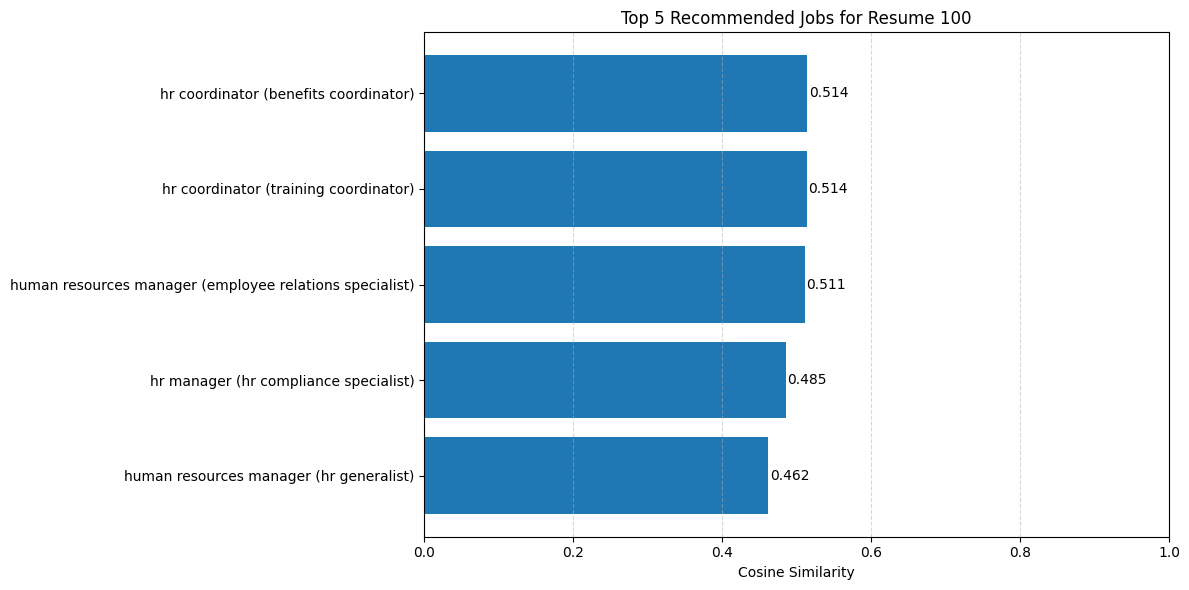

In [73]:
# Data for plotting
labels = [
    f"{jd_df.iloc[i]['Job Title']} ({jd_df.iloc[i]['Role']})"
    for i in top5
]

plt.figure(figsize=(12,6))
bars = plt.barh(labels[::-1], similarities[::-1])

plt.xlabel("Cosine Similarity")
plt.title(f"Top 5 Recommended Jobs for Resume {resume_index}")

for bar, score in zip(bars, similarities[::-1]):
    plt.text(
        bar.get_width()+0.002,
        bar.get_y()+bar.get_height()/2,
        f"{score:.3f}",
        va='center'
    )

plt.xlim(0,1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
title=f"Top 5 Recommended Jobs for Resume {resume_index}.png"
plt.savefig(title, dpi=300, bbox_inches='tight')
plt.show()

In [57]:
jd_index =20
scores = similarity_matrix[:, jd_index]
top_candidates = np.argsort(scores)[::-1][:5]

print(jd_df.loc[20, ["Job Title", "Role", "skills"]])

for rank, idx in enumerate(top_candidates, 1):
    print(f"Candidate {rank}")
    print("Resume ID:", resume_df.iloc[idx]["ID"])
    print("Category:", resume_df.iloc[idx]["Category"])
    print("Similarity:", round(scores[idx], 4))
    print("-"*50)

Job Title                                    software engineer
Role                                         backend developer
skills       proficiency in one or more backend programming...
Name: 20, dtype: object
Candidate 1
Resume ID: 22351830
Category: consultant
Similarity: 0.5145
--------------------------------------------------
Candidate 2
Resume ID: 20674668
Category: information-technology
Similarity: 0.514
--------------------------------------------------
Candidate 3
Resume ID: 83816738
Category: information-technology
Similarity: 0.5108
--------------------------------------------------
Candidate 4
Resume ID: 12415691
Category: designer
Similarity: 0.4854
--------------------------------------------------
Candidate 5
Resume ID: 24643412
Category: consultant
Similarity: 0.462
--------------------------------------------------


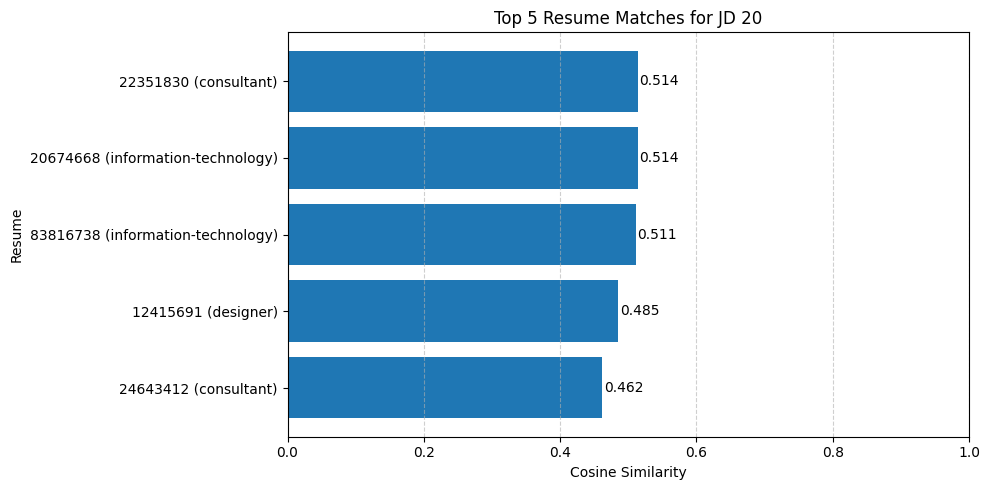

In [58]:
# Data for plotting
resume_labels = [
    f"{resume_df.iloc[i]['ID']} ({resume_df.iloc[i]['Category']})"
    for i in top_candidates
]
similarities = [scores[i] for i in top_candidates]

# Plot
plt.figure(figsize=(10, 5))
bars = plt.barh(resume_labels[::-1], similarities[::-1])

plt.xlabel("Cosine Similarity")
plt.ylabel("Resume")
plt.title(f"Top 5 Resume Matches for JD {jd_index}")

# Add similarity values on bars
for bar, score in zip(bars, similarities[::-1]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{score:.3f}",
        va='center'
    )

plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
title=f"Top 5 Resume Matches for JD {jd_index}.png"
plt.savefig(title, dpi=300, bbox_inches='tight')
plt.show()

In [26]:
#pip install keybert

In [27]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

In [31]:
import re

def clean_skills(text):
    # split on commas/whitespace
    tokens = re.split(r'[,\s]+', text)
    cleaned = []
    for t in tokens:
        t = t.lower().strip()
        t = re.sub(r'[()]', '', t)          # remove parentheses
        t = t.rstrip('.,)')                  # remove trailing punctuation like "git)" -> "git", "e.g." -> "e.g"
        t = t.strip()
        if t in ('e.g', 'eg', 'ie', 'i.e', '') :
            continue
        if t in stop_words:
            continue
        if len(t) <= 1:                      # drop stray single chars like 'r' from "(python, r)"
            continue
        cleaned.append(t)
    return sorted(set(cleaned))

In [59]:
resume_index = 5
scores = similarity_matrix[resume_index]
top_candidates = np.argsort(scores)[::-1][:5]
resume_text = resume_df.iloc[resume_index]["Clean Resume_str"].lower()
jobs = []
matched_counts = []
missing_counts = []

for rank, idx in enumerate(top_candidates, 1):
    print(f"\nRank {rank}")
    print("Job:", jd_df.iloc[idx]["Job Title"])
    jd_skills = jd_df.iloc[idx]["skills"].split()
    jd_skills = clean_skills(jd_df.iloc[idx]["skills"])
    matched = [skill for skill in jd_skills if skill.lower() in resume_text]
    jobs.append(jd_df.iloc[idx]["Job Title"])
    matched_counts.append(len(matched))
    missing_counts.append(len(jd_skills) - len(matched))
    print("JD Skills      :", jd_skills)
    print("Matched Skills :", matched)
    print("Missing Skills :", list(set(jd_skills) - set(matched)))
    print("-"*100)
print(matched_counts,missing_counts)


Rank 1
Job: hr generalist
JD Skills      : ['communication', 'employee', 'hr', 'hris', 'human', 'information', 'keeping', 'onboarding', 'record', 'recruitment', 'resources', 'skills', 'systems']
Matched Skills : ['employee', 'hr', 'human', 'information', 'recruitment']
Missing Skills : ['communication', 'resources', 'skills', 'keeping', 'systems', 'hris', 'record', 'onboarding']
----------------------------------------------------------------------------------------------------

Rank 2
Job: human resources manager
JD Skills      : ['communication', 'employee', 'hr', 'policies', 'procedures', 'recruitment', 'relations', 'skills']
Matched Skills : ['employee', 'hr', 'recruitment']
Missing Skills : ['communication', 'relations', 'skills', 'policies', 'procedures']
----------------------------------------------------------------------------------------------------

Rank 3
Job: hr manager
JD Skills      : ['development', 'employee', 'hr', 'leadership', 'management', 'planning', 'policy', '

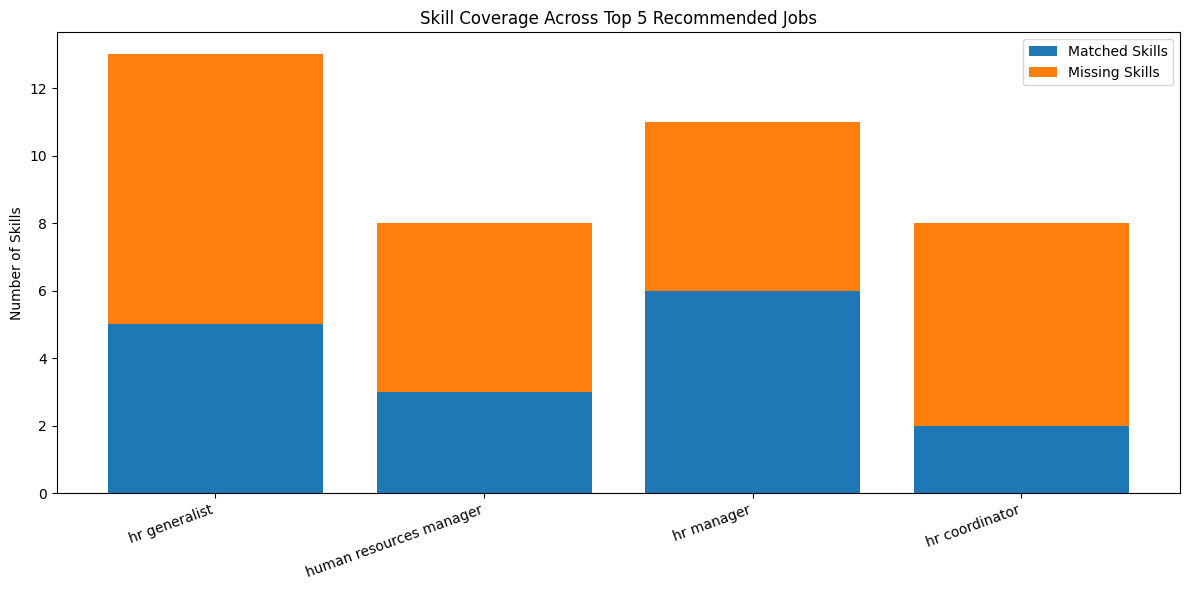

In [60]:
plt.figure(figsize=(12,6))

plt.bar(jobs, matched_counts, label="Matched Skills")
plt.bar(jobs, missing_counts, bottom=matched_counts, label="Missing Skills")

plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of Skills")
plt.title("Skill Coverage Across Top 5 Recommended Jobs")
plt.legend()
title=f"Skill Coverage Across Top 5 Recommended Jobs{resume_index}.png"
plt.tight_layout()
plt.savefig(title, dpi=300, bbox_inches='tight')
plt.show()

In [69]:
user_input = input("Enter skills: ")
resume_skills = [s.strip().lower() for s in user_input.split()]
jobs = []
matched_counts = []
missing_counts = []
# Encode the WHOLE input as one sentence, matching how JD/resume text was built
resume_text_combined = " ".join(resume_skills)
resume_embedding_pred = model.encode([resume_text_combined], convert_to_numpy=True)

similarity_scores = cosine_similarity(resume_embedding_pred, jd_embeddings)[0]  # shape: (num_jds,)

top_candidates = np.argsort(similarity_scores)[::-1][:5]   # <-- argsort the array, not max()

resume_text = resume_text_combined  # for substring matching below

for rank, idx in enumerate(top_candidates, 1):
    print(f"\nRank {rank}")
    print("Job:", jd_df.iloc[idx]["Job Title"])
    jd_skills = jd_df.iloc[idx]["skills"].split()
    jd_skills = clean_skills(jd_df.iloc[idx]["skills"])
    matched = [skill for skill in jd_skills if skill.lower() in resume_text]
    jobs.append(jd_df.iloc[idx]["Job Title"])
    matched_counts.append(len(matched))
    missing_counts.append(len(jd_skills) - len(matched))
    print("JD Skills      :", jd_skills)
    print("Matched Skills :", matched)
    print("Missing Skills :", list(set(jd_skills) - set(matched)))
    print("-"*100)

Enter skills:  Frontend Developer with 3 years of experience building responsive web applications. Proficient in HTML, CSS, and JavaScript. Skilled in frontend frameworks including React and Angular. Strong focus on user experience (UX) design and cross-browser compatibility. Built and maintained multiple client-facing websites using modern component-based architecture.



Rank 1
Job: software engineer
JD Skills      : ['angular', 'compatibility', 'control', 'cross-browser', 'css', 'design', 'experience', 'frameworks', 'frontend', 'git', 'html', 'javascript', 'like', 'optimization', 'performance', 'proficiency', 'react', 'responsive', 'version', 'vue.js', 'web']
Matched Skills : ['angular', 'compatibility', 'cross-browser', 'css', 'design', 'experience', 'frameworks', 'frontend', 'html', 'javascript', 'react', 'responsive', 'web']
Missing Skills : ['performance', 'vue.js', 'git', 'version', 'control', 'proficiency', 'optimization', 'like']
----------------------------------------------------------------------------------------------------

Rank 2
Job: web developer
JD Skills      : ['angular', 'css', 'experience', 'frameworks', 'frontend', 'html', 'javascript', 'react', 'user', 'ux']
Matched Skills : ['angular', 'css', 'experience', 'frameworks', 'frontend', 'html', 'javascript', 'react', 'user', 'ux']
Missing Skills : []
-------------------------------

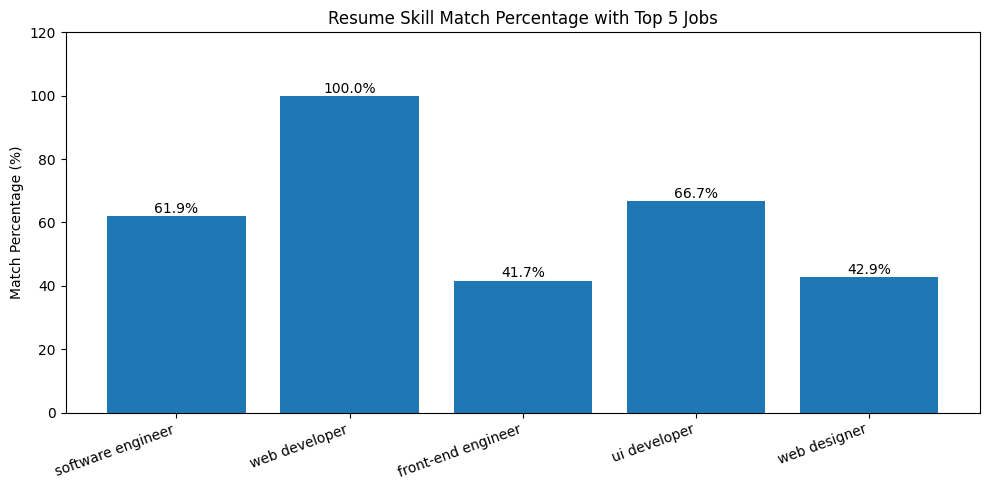

In [70]:
match_percentage = []

for m, miss in zip(matched_counts, missing_counts):
    total = m + miss
    match_percentage.append((m / total) * 100 if total > 0 else 0)

plt.figure(figsize=(10,5))
bars = plt.bar(jobs, match_percentage)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Match Percentage (%)")
plt.title("Resume Skill Match Percentage with Top 5 Jobs")
plt.ylim(0,120)

for bar, pct in zip(bars, match_percentage):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        pct + 1,
        f"{pct:.1f}%",
        ha='center'
    )

plt.tight_layout()
plt.savefig("Resume Skill Match Percentage with Top 5 Jobs_pred.png", dpi=300, bbox_inches='tight')
plt.show()

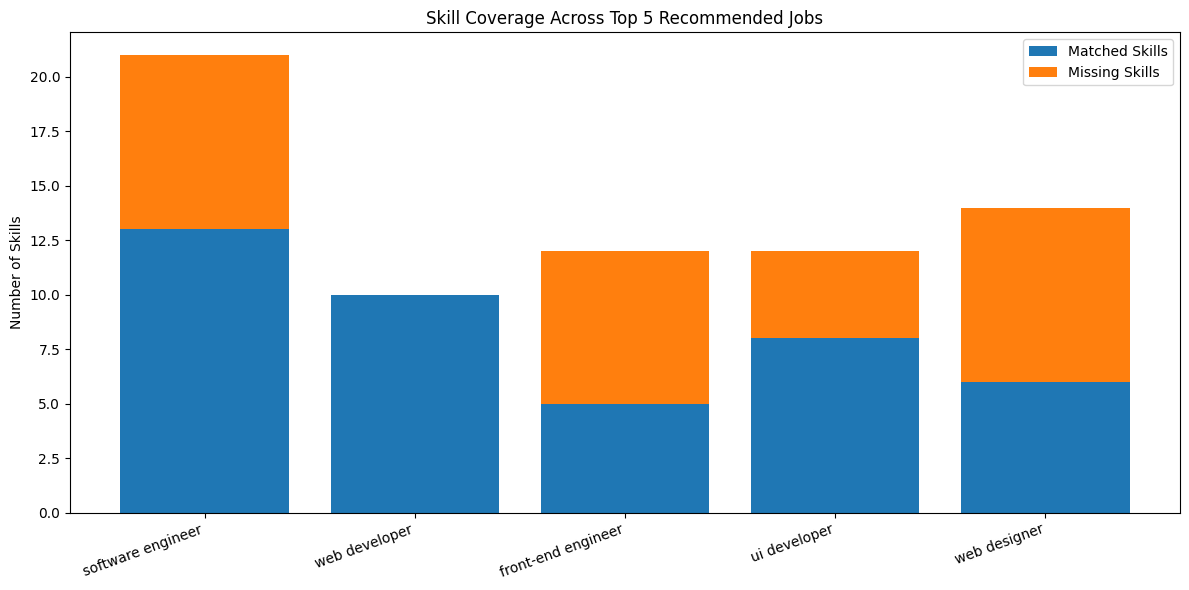

In [71]:
plt.figure(figsize=(12,6))

plt.bar(jobs, matched_counts, label="Matched Skills")
plt.bar(jobs, missing_counts, bottom=matched_counts, label="Missing Skills")

plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of Skills")
plt.title("Skill Coverage Across Top 5 Recommended Jobs")
plt.legend()

plt.tight_layout()
plt.savefig("Skill Coverage Across Top 5 Recommended Jobs_pred.png", dpi=300, bbox_inches='tight')
plt.show()

In [63]:
import joblib

model.save("sentence_transformer_model")
joblib.dump(jd_embeddings, "jd_embeddings.pkl")
joblib.dump(resume_embeddings, "resume_embeddings.pkl")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s]


['resume_embeddings.pkl']

In [66]:
jd_df.to_csv("Processed JD.csv",index=False)
resume_df.to_csv("Processed Resumes.csv",index=False)